In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import ttest_ind
from matplotlib.collections import PolyCollection

In [2]:
### Fig.4(B)
data7 = pd.read_pickle('G_ripple_data7.pkl')
data7.head(2)

,WinnerID,AuthorID,delta_C_coauthor,similarity
0,W285,C1,-0.031272,0.938077
1,W1026,C2,-0.013791,0.966126


In [3]:
data7["similarity_group"] = pd.qcut(data7["similarity"], q=[0, 0.35, 0.7, 1.0],labels=["0-35%", "35-70%", ">70%"])

In [4]:
from scipy.stats import ttest_rel
results = []
for name, group in data7.groupby("similarity_group"):
    d1 = group["delta_C_coauthor"].dropna()  
    mean1 = d1.mean()
    ci95_1 = 1.96 * np.std(d1, ddof=1) / np.sqrt(len(d1))
    results.append({
        "similarity_group": name,
        "delta_C_coauthor": mean1,
        "ci95_coauthor": ci95_1})
summary_df = pd.DataFrame(results)
summary_df

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1765026/2858428670.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in data7.groupby("similarity_group"):


,similarity_group,delta_C_coauthor,ci95_coauthor
0,0-35%,0.061776,0.002890
1,35-70%,0.053959,0.001680
2,>70%,0.041436,0.001271


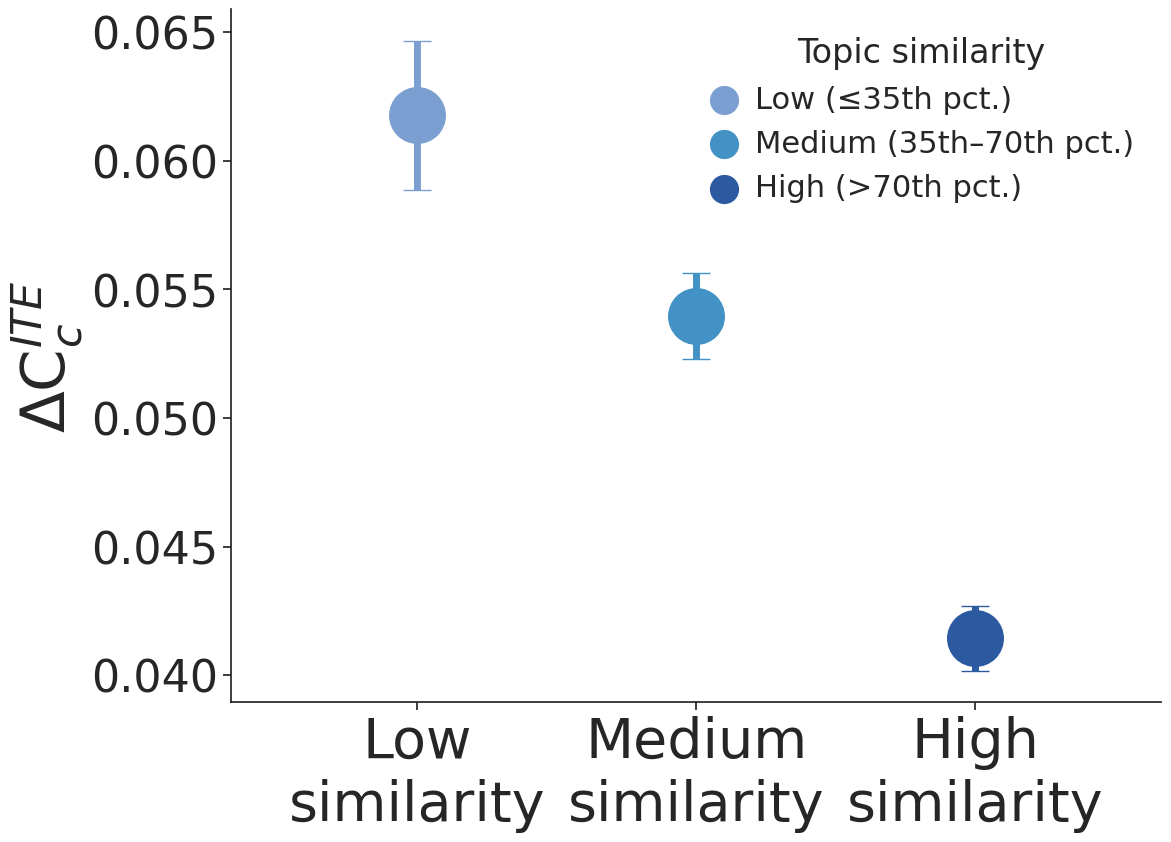

In [5]:
sns.set(font_scale=1.5)
sns.set(style="ticks")
fig, ax = plt.subplots(figsize=(12,9))
##similarity1
plt.scatter(0.2, 0.061776, marker='o', s=1600, edgecolors='#7C9FD2', facecolors='#7C9FD2', zorder=0, label='Low (≤35th pct.)')
plt.errorbar(0.2, 0.061776, yerr=0.002890, color='#7C9FD2', capsize=10,elinewidth=5)
##similarity2
plt.scatter(0.5, 0.053959, marker='o', s=1600, edgecolors='#4292C6', facecolors='#4292C6', zorder=0, label='Medium (35th–70th pct.)')
plt.errorbar(0.5, 0.053959, yerr=0.001680, color='#4292C6', capsize=10,elinewidth=5)
##similarity3
plt.scatter(0.8, 0.041436, marker='o', s=1600, edgecolors='#2C5AA0', facecolors='#2C5AA0', zorder=0, label='High (>70th pct.)')
plt.errorbar(0.8, 0.041436, yerr=0.001271, color='#2C5AA0', capsize=10,elinewidth=5)
plt.ylabel(r"ΔC$^{ITE}_{c}$", fontsize=44)
plt.xticks([0.2, 0.5,0.8], ['Low\nsimilarity', 'Medium\nsimilarity','High\nsimilarity'], fontsize=40)
plt.yticks(fontsize=32)
plt.xlim(0, 1)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(fontsize=22,frameon=False,loc='upper right',
    title="Topic similarity",title_fontsize=24,
    scatterpoints=1,    markerscale=0.5,     
    handlelength=1.0,    handletextpad=0.5)
plt.show()

In [6]:
### Fig.4(C)
data15 = pd.read_pickle('G_ripple_data15.pkl')
data15.head(2)

,similarity_group,award_year,delta_C_coauthor,group
0,Low,1969,0.133694,Coauthor
1,Low,1970,0.237404,Coauthor


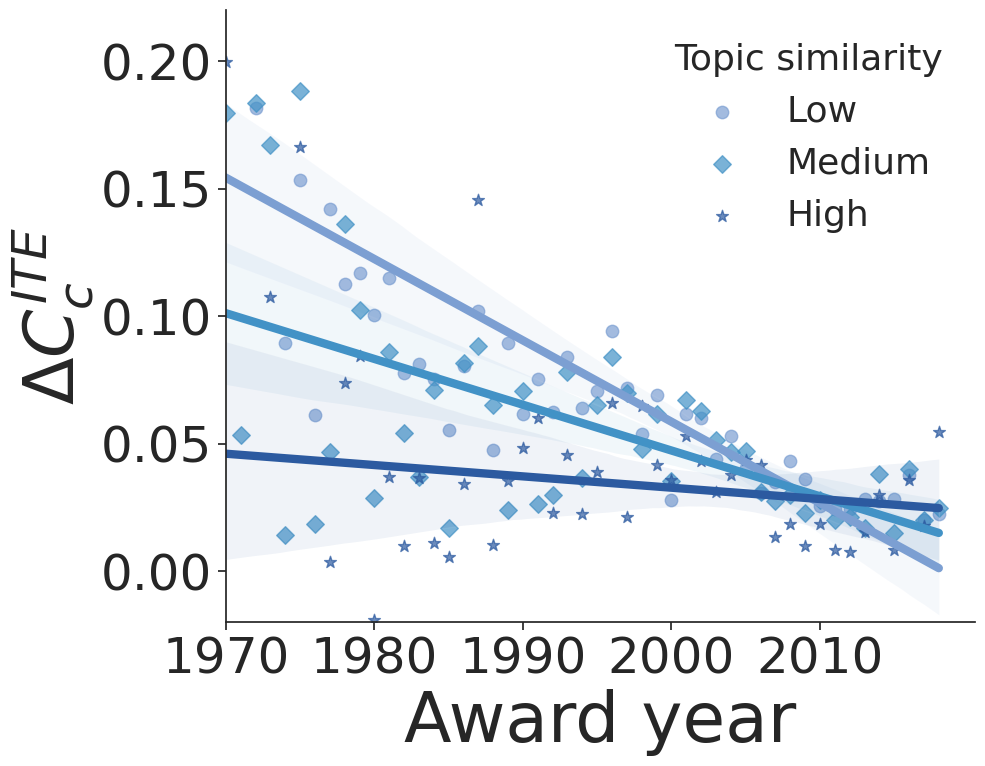

In [7]:
sns.set(style="ticks", font_scale=1.5)
palette = {'Low': '#7C9FD2','Medium': '#4292C6','High': '#2C5AA0'}
g = sns.lmplot(data=data15,
    x="award_year",y="delta_C_coauthor",hue="similarity_group",         
    ci=95,order=1,height=8,aspect=1,palette=palette, markers=["o", "D", "*"],
    scatter_kws={"s": 80, "alpha": 0.7},line_kws={"linewidth": 6})
for ax in g.axes.flat:
    for coll in ax.collections:
        if isinstance(coll, PolyCollection):
            coll.set_alpha(0.07)  
plt.xlabel("Award year", fontsize=50)
plt.ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
plt.xlim(1970, None)
plt.xticks(range(1970, 2020,10),fontsize=36)
plt.yticks(fontsize=36)
plt.ylim(-0.02, 0.22)
if g._legend is not None:
    g._legend.remove()
plt.legend(title="Topic similarity",loc='upper right',     
    frameon=False,fontsize=26,title_fontsize=26)
plt.tight_layout()
plt.show()

In [8]:
### Fig.4(D)
data16 = pd.read_pickle('G_ripple_data16.pkl')
data16.head(2)

,similarity_group,delta_T,delta_C_coauthor,group
0,Low,1,0.182006,Coauthor
1,Low,2,0.056192,Coauthor


/usr/local/anaconda2025/lib/python3.11/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/anaconda2025/lib/python3.11/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/anaconda2025/lib/python3.11/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)


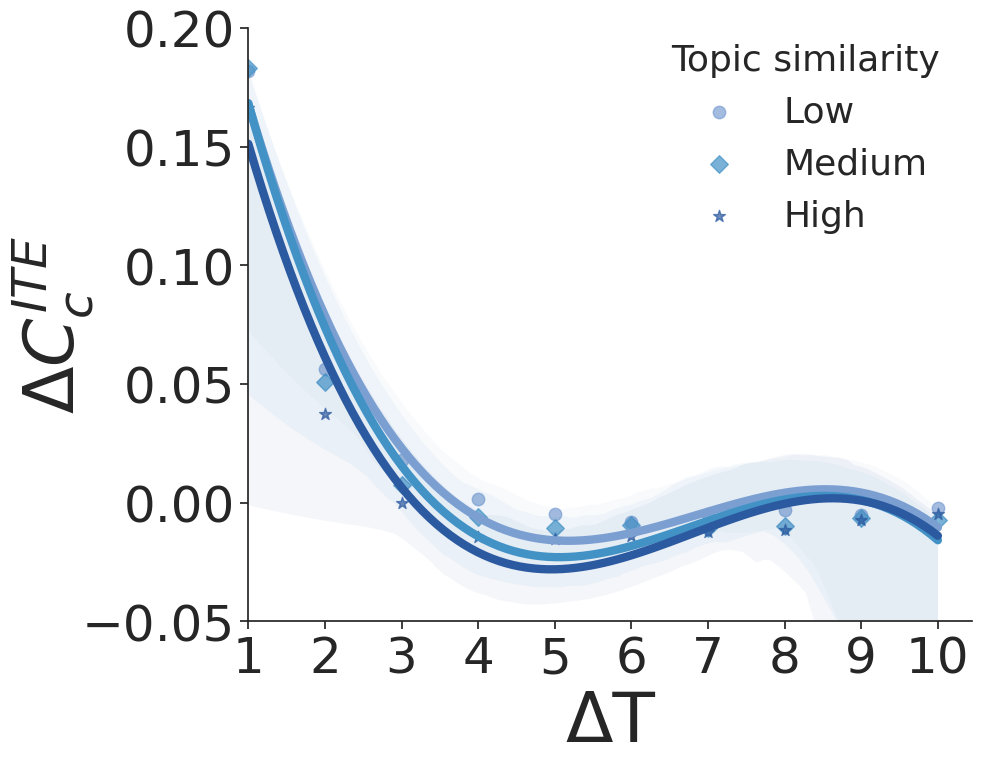

In [9]:
sns.set(style="ticks", font_scale=1.5)
palette = {'Low': '#7C9FD2','Medium': '#4292C6','High': '#2C5AA0'}
g = sns.lmplot(data=data16,
    x="delta_T",y="delta_C_coauthor",hue="similarity_group",         
    ci=95,order=3,height=8,aspect=1,palette=palette,markers=["o", "D", "*"],
    scatter_kws={"s": 80, "alpha": 0.7},line_kws={"linewidth": 6})
for ax in g.axes.flat:
    for coll in ax.collections:
        if isinstance(coll, PolyCollection):
            coll.set_alpha(0.05) 
plt.ylim(-0.05,0.2)
plt.xlim(1, None)
plt.xticks(range(1, 11))
ax = g.ax
ax.set_xlabel("ΔT", fontsize=50)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50, labelpad=-10)
ax.tick_params(axis='x', labelsize=36)
ax.tick_params(axis='y', labelsize=36)
ymin, ymax = ax.get_ylim()
ax.set_yticks(np.arange(round(ymin, 2), round(ymax + 0.05, 2), 0.05))
if g._legend is not None:
    g._legend.remove()
ax.legend(title="Topic similarity",loc='upper right', bbox_to_anchor=(1, 1.03),    
    frameon=False,fontsize=26,title_fontsize=26)
plt.tight_layout()
plt.show()

In [10]:
### Fig.4(E)
data17 = pd.read_pickle('G_ripple_data17.pkl')
data17.head(2)

,similarity_group,Award age,delta_C_coauthor,group
1,Low,25,0.400968,Coauthor
2,Low,26,0.047273,Coauthor


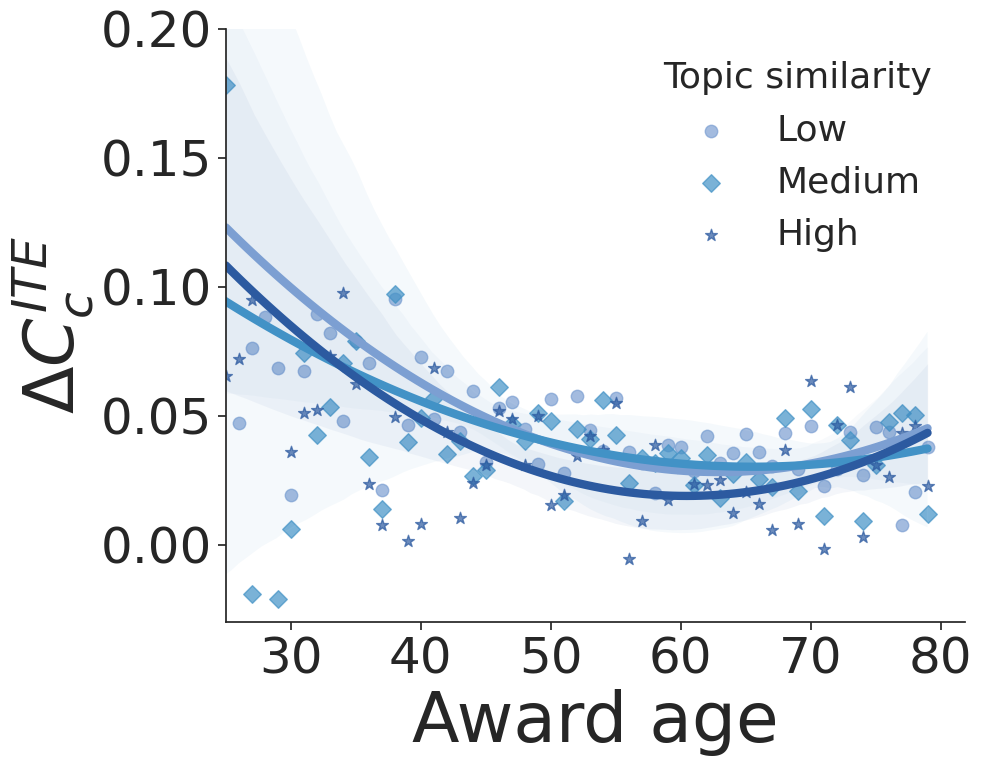

In [11]:
sns.set(style="ticks", font_scale=1.5)
palette = {'Low': '#7C9FD2','Medium': '#4292C6','High': '#2C5AA0'}
g = sns.lmplot(data=data17,
    x="Award age",y="delta_C_coauthor",hue="similarity_group",         
    ci=95,order=2,height=8,aspect=1,palette=palette,markers=["o", "D", "*"],
    scatter_kws={"s": 80, "alpha": 0.7},line_kws={"linewidth": 6})
for ax in g.axes.flat:
    for coll in ax.collections:
        if isinstance(coll, PolyCollection):
            coll.set_alpha(0.05) 
plt.ylim(-0.03,0.2)
plt.xlabel("Award age", fontsize=50)
plt.ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
plt.xlim(25, None)
plt.xticks(range(30, 81,10),fontsize=36)
plt.yticks(fontsize=36)
if g._legend is not None:
    g._legend.remove()
plt.legend(title="Topic similarity",loc='upper right',     
    frameon=False,fontsize=26,title_fontsize=26)
plt.tight_layout()
plt.show()

In [12]:
### Fig.4(F)
data18 = pd.read_pickle('G_ripple_data18.pkl')
data18.head(2)

,matched_group,delta_C_coauthor,AuthorID,WinnerID,genderLabel,similarity_group
0,M1,0.345092,C118278,W2363,male,Low
1,M2,0.863965,C151552,W431,male,High


In [13]:
aggregations = {'mean': ('delta_C_coauthor', np.mean),
    '95% CI': ('delta_C_coauthor', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result1 = data18.groupby(["genderLabel", "similarity_group"]).agg(**aggregations)
result1.reset_index(inplace=True)
result1

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1765026/3300076836.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result1 = data18.groupby(["genderLabel", "similarity_group"]).agg(**aggregations)
/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1765026/3300076836.py:3: FutureWarning: The provided callable <function mean at 0x1481a40d99e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result1 = data18.groupby(["genderLabel", "similarity_group"]).agg(**aggregations)


,genderLabel,similarity_group,mean,95% CI
0,female,Low,0.042881,0.002481
1,female,Medium,0.034523,0.002366
2,female,High,0.031770,0.002531
3,male,Low,0.035508,0.000974
4,male,Medium,0.031224,0.000986
5,male,High,0.022565,0.001019


In [14]:
result = pd.DataFrame({
    "genderLabel": ["Female", "Female", "Female", "Male", "Male", "Male"],
    "similarity_group": ["Low", "Medium", "High",
                         "Low", "Medium", "High"],
    "mean": [0.042881, 0.034523, 0.031770,0.035508, 0.031224, 0.022565],
    "CI": [0.002481, 0.002366, 0.002531, 0.000974, 0.000986, 0.001019]})

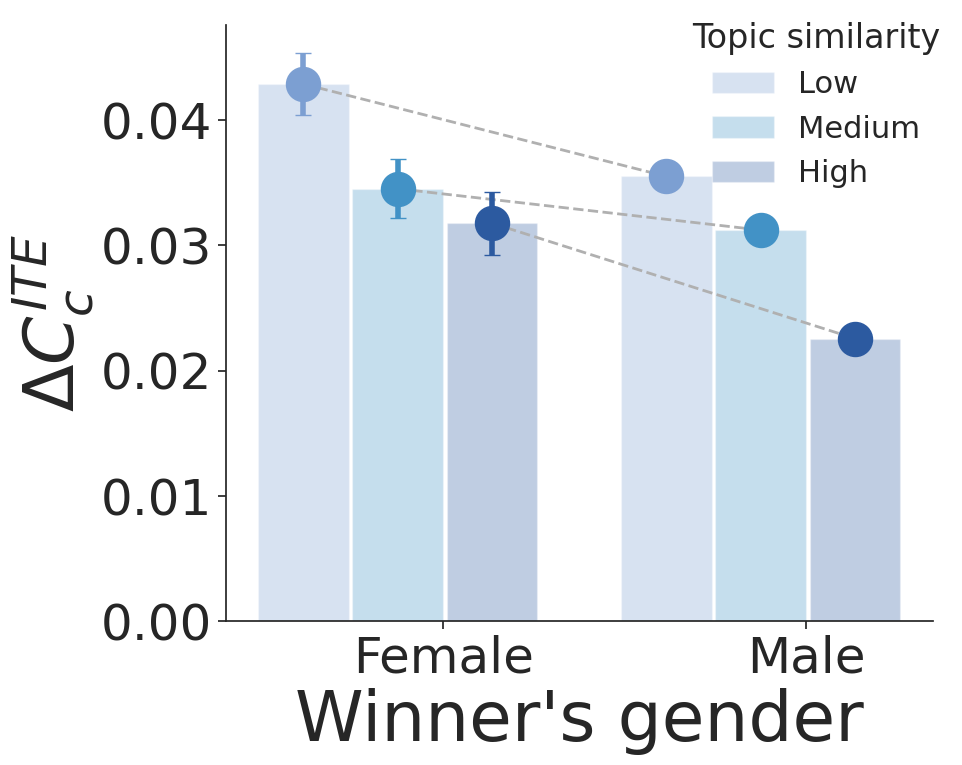

In [15]:
bar_width = 0.25
gap_width = 0.05
x = np.arange(2)
tick_label = ["Female", "Male"]
palette = {'Low': '#7C9FD2','Medium': '#4292C6','High': '#2C5AA0'}
fig, ax = plt.subplots(figsize=(10, 8))

for i, tie in enumerate(["Low", "Medium", "High"]):
    subset = result[result["similarity_group"] == tie]
    x_positions = x + i * (bar_width + 0.01)
    ax.bar(x_positions, subset["mean"], width=bar_width,
           color=palette[tie], label=tie, alpha=0.3)

    ax.scatter(x_positions, subset["mean"], s=600,
               edgecolors=palette[tie], facecolors=palette[tie], zorder=3)
    ax.errorbar(x_positions, subset["mean"], yerr=subset["CI"],
                color=palette[tie], capsize=6, elinewidth=4,linestyle='none')
    ax.plot(x_positions, subset["mean"], linestyle="--", color="#B0B0B0", linewidth=2, zorder=1)

ax.set_xlabel("Winner's gender", fontsize=50)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
ax.set_xticks(x + (1.5 * bar_width + 0.01))
ax.set_xticklabels(tick_label, fontsize=36)
ax.tick_params(axis="y", labelsize=36)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
legend = ax.legend(title="Topic similarity", fontsize=22, title_fontsize=24,
                   loc="upper right", bbox_to_anchor=(1.05, 1.05),
                   frameon=False)

plt.tight_layout()
plt.show()

In [16]:
### Fig.4(G)
data19 = pd.read_pickle('G_ripple_data19.pkl')
data19.head(2)

,matched_group,delta_C_coauthor,AuthorID,WinnerID,awardLabel,award_prestige,prestige_group,is_top5,similarity_group
0,M1,0.345092,C112912,W2273,Fellow of the Royal Society,33630.6,High,1,Low
1,M147,0.074300,C102482,W2273,Fellow of the Royal Society,33630.6,High,1,Low


In [17]:
aggregations = {
    'mean': ('delta_C_coauthor', np.mean),
    '95% CI': ('delta_C_coauthor', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result1 = data19.groupby(["prestige_group", "similarity_group"]).agg(**aggregations)
result1.reset_index(inplace=True)
result1

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1765026/1870482676.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result1 = data19.groupby(["prestige_group", "similarity_group"]).agg(**aggregations)
/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1765026/1870482676.py:4: FutureWarning: The provided callable <function mean at 0x1481a40d99e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result1 = data19.groupby(["prestige_group", "similarity_group"]).agg(**aggregations)


,prestige_group,similarity_group,mean,95% CI
0,Low,Low,0.040603,0.001306
1,Low,Medium,0.033703,0.001333
2,Low,High,0.022985,0.001391
3,High,Low,0.032526,0.001302
4,High,Medium,0.029562,0.001289
5,High,High,0.023785,0.001339


In [18]:
result = pd.DataFrame({"prestige_group": ["Low", "Low", "Low", "High", "High", "High"],
    "similarity_group": ["Low", "Medium", "High","Low", "Medium", "High"],
    "mean": [0.040603, 0.033703, 0.022985,0.032526, 0.029562, 0.023785],
    "CI": [0.001306, 0.001333, 0.001391,0.001302, 0.001289, 0.001339]})

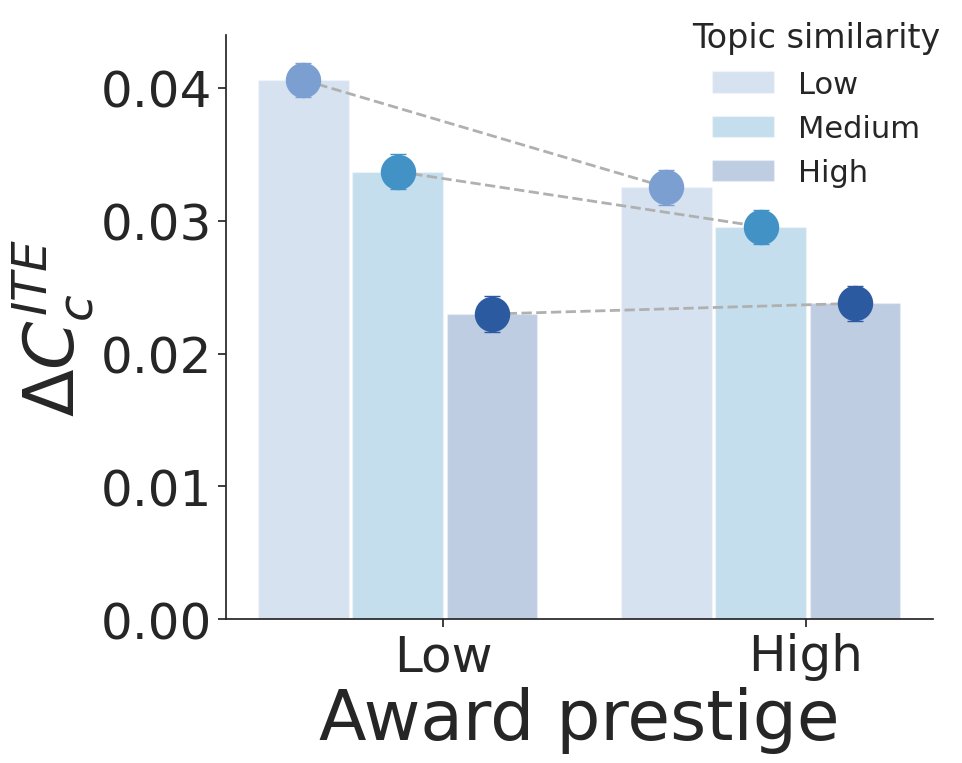

In [19]:
bar_width = 0.25
gap_width = 0.05
x = np.arange(2)  
tick_label = ["Low", "High"]
palette = {'Low': '#7C9FD2','Medium': '#4292C6','High': '#2C5AA0'}
fig, ax = plt.subplots(figsize=(10, 8))

for i, tie in enumerate(["Low", "Medium", "High",]):
    subset = result[result["similarity_group"] == tie].sort_values(
        "prestige_group", key=lambda c: c.map({"Low": 0, "High": 1})
    )
    x_positions = x + i * (bar_width + 0.01)
    ax.bar(x_positions, subset["mean"], width=bar_width,
           color=palette[tie], label=tie, alpha=0.3, zorder=1)
    
    ax.scatter(x_positions, subset["mean"], s=600,
               edgecolors=palette[tie], facecolors=palette[tie], zorder=3)
    ax.errorbar(x_positions, subset["mean"], yerr=subset["CI"],
                color=palette[tie], capsize=6, elinewidth=4, linestyle='none', zorder=3)
    ax.plot(x_positions, subset["mean"], linestyle="--",color="#B0B0B0", linewidth=2, zorder=1)

ax.set_xlabel("Award prestige", fontsize=50)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
ax.set_xticks(x + (1.5 * bar_width + 0.01))
ax.set_xticklabels(tick_label, fontsize=36)
ax.tick_params(axis="y", labelsize=36)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
legend = ax.legend(title="Topic similarity", fontsize=22, title_fontsize=24,
                   loc="upper right", bbox_to_anchor=(1.05, 1.07),
                   frameon=False)
plt.tight_layout()
plt.show()

In [22]:
### Fig.4(H)
aggregations = {
    'mean': ('delta_C_coauthor', np.mean),
    '95% CI': ('delta_C_coauthor', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result1 = data19.groupby(["is_top5", "similarity_group"]).agg(**aggregations)
result1.reset_index(inplace=True)
result1

/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1765026/897896525.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result1 = data19.groupby(["is_top5", "similarity_group"]).agg(**aggregations)
/var/tmp/pbs.3850105.hpc-pbs-sched1/ipykernel_1765026/897896525.py:5: FutureWarning: The provided callable <function mean at 0x1481a40d99e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result1 = data19.groupby(["is_top5", "similarity_group"]).agg(**aggregations)


,is_top5,similarity_group,mean,95% CI
0,0,Low,0.037694,0.001062
1,0,Medium,0.032219,0.001079
2,0,High,0.022316,0.001111
3,1,Low,0.033648,0.001866
4,1,Medium,0.029965,0.001817
5,1,High,0.026733,0.001947


In [23]:
result = pd.DataFrame({"is_top5": [0, 0, 0, 1, 1, 1],
    "similarity_group": ["Low", "Medium", "High", "Low", "Medium", "High"],
    "mean": [0.037694, 0.032219, 0.022316,0.033648, 0.029965, 0.026733],
    "CI": [0.001062, 0.001079, 0.001111,0.001866, 0.001817, 0.001947]})

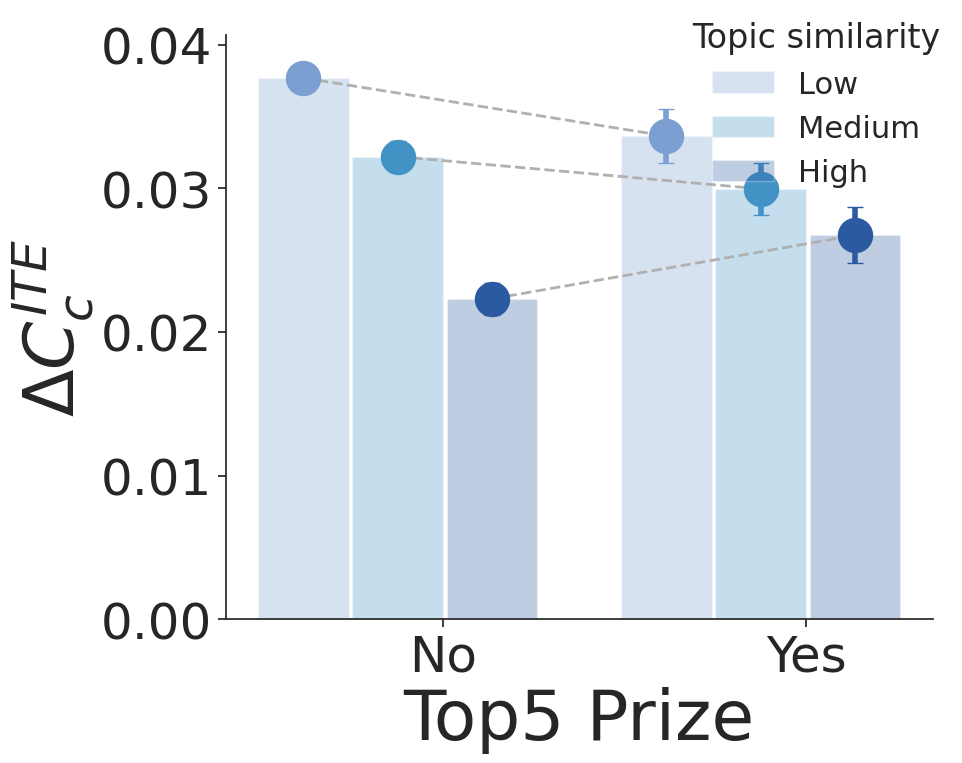

In [24]:
bar_width = 0.25
gap_width = 0.05
x = np.arange(2)  
tick_label = ["No", "Yes"]
palette = {'Low': '#7C9FD2','Medium': '#4292C6','High': '#2C5AA0'}
fig, ax = plt.subplots(figsize=(10, 8))

for i, tie in enumerate(["Low", "Medium", "High",]):
    subset = (result[result["similarity_group"] == tie].sort_values("is_top5", ascending=True))
    x_positions = x + i * (bar_width + 0.01)
    ax.bar(x_positions, subset["mean"], width=bar_width,
           color=palette[tie], label=tie, alpha=0.3, zorder=1)
    
    ax.scatter(x_positions, subset["mean"], s=600,
               edgecolors=palette[tie], facecolors=palette[tie], zorder=3)
    ax.errorbar(x_positions, subset["mean"], yerr=subset["CI"],
                color=palette[tie], capsize=6, elinewidth=4, linestyle='none', zorder=3)
    ax.plot(x_positions, subset["mean"], linestyle="--",color="#B0B0B0", linewidth=2, zorder=1)

ax.set_xlabel("Top5 Prize", fontsize=50)
ax.set_ylabel(r"$\Delta C^{ITE}_{c}$", fontsize=50)
ax.set_xticks(x + (1.5 * bar_width + 0.01))
ax.set_xticklabels(tick_label, fontsize=36)
ax.tick_params(axis="y", labelsize=36)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
legend = ax.legend(title="Topic similarity", fontsize=22, title_fontsize=24,
                   loc="upper right", bbox_to_anchor=(1.05, 1.07),
                   frameon=False)
plt.tight_layout()
plt.show()